In [1]:
from torchdiffeq import odeint
from importlib import reload
import CNF
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from tqdm import tqdm
from IPython.display import display
import os

DEVICE = "cpu"

In [2]:

print(os.getenv("CUDA_VISIBLE_DEVICES"), torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(i, torch.cuda.get_device_properties(i))

None 7
0 _CudaDeviceProperties(name='NVIDIA RTX A4000', major=8, minor=6, total_memory=15973MB, multi_processor_count=48, uuid=aa969728-9b37-ac58-7855-3f03494fb9e8, pci_bus_id=59, pci_device_id=0, pci_domain_id=0, L2_cache_size=4MB)
1 _CudaDeviceProperties(name='NVIDIA RTX A4000', major=8, minor=6, total_memory=15973MB, multi_processor_count=48, uuid=a922981b-b848-d027-b714-170d91808e71, pci_bus_id=60, pci_device_id=0, pci_domain_id=0, L2_cache_size=4MB)
2 _CudaDeviceProperties(name='NVIDIA RTX A4000', major=8, minor=6, total_memory=15973MB, multi_processor_count=48, uuid=ec74220d-78d7-cc47-69fc-0de1fb580944, pci_bus_id=94, pci_device_id=0, pci_domain_id=0, L2_cache_size=4MB)
3 _CudaDeviceProperties(name='NVIDIA RTX A4000', major=8, minor=6, total_memory=15973MB, multi_processor_count=48, uuid=972b1ac9-5c27-384f-8f3b-b917fd06deba, pci_bus_id=95, pci_device_id=0, pci_domain_id=0, L2_cache_size=4MB)
4 _CudaDeviceProperties(name='NVIDIA RTX A4000', major=8, minor=6, total_memory=15973MB, 

In [2]:
FIELDS = 16
HIDDEN_LAYERS = 8
STEPS = 1000
SAVE_AFTER = 50
BATCH_SIZE = 64
EPOCHES = 50

In [3]:
reload(CNF)

<module 'CNF' from '/home/iskovskihal/projects/scince_school/CNF.py'>

In [4]:
def get_batch(n: int):
    X, _ = make_circles(n, noise=0.06, factor=0.5)
    return torch.tensor(X, dtype=torch.float32, device=DEVICE)

In [5]:
dataset = get_batch(10000)
dataset = torch.utils.data.TensorDataset(dataset)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

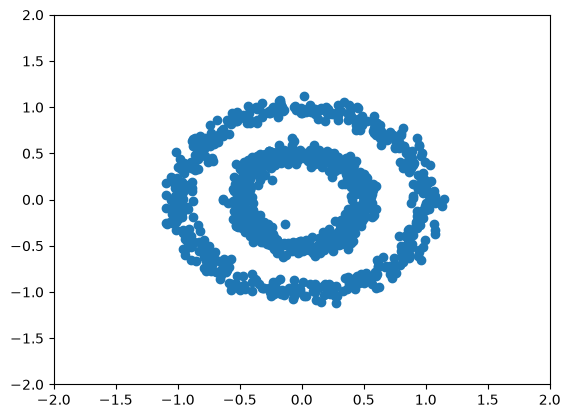

In [6]:
fig, ax = plt.subplots()

# Координаты сетки
X = get_batch(1000)
X = X.cpu().numpy()
x, y = X[:, 0], X[:, 1]
ax.scatter(x, y)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
# plt.colorbar()
plt.show()

In [7]:
reload(CNF)
# cpnf: CNF.Cpnf = CNF.Cpnf(2)
# cpnf.to(DEVICE)
hidden_features = HIDDEN_LAYERS
filds_num = FIELDS
cpnflist = torch.nn.ModuleList([CNF.Cpnf(2).to(DEVICE) for i in range(filds_num)])
time_gates = torch.nn.ModuleList([torch.nn.Sequential(torch.nn.Linear(1, hidden_features),
                                  torch.nn.ReLU(),
                                  torch.nn.Linear(hidden_features, hidden_features),
                                  torch.nn.ReLU(),
                                  torch.nn.Linear(hidden_features, 1),
                                  torch.nn.Sigmoid()) for i in range(filds_num)])
cnf = CNF.CNF(fields=cpnflist, activations=time_gates).to(DEVICE)
# cnf.compile()
wraped = CNF.Wraper(cnf)

In [8]:
Y, jac = wraped.forward(torch.tensor([[0., 1], [1, 0], [1, 1]], device=DEVICE), log_jac=True)
Y1 = wraped.forward(torch.tensor([[0., 1], [1, 0], [1, 1]], device=DEVICE))
Y, jac, Y1


(tensor([[0.3028, 1.8396],
         [1.6906, 1.3003],
         [2.3493, 2.2704]]),
 tensor([-1.7887,  0.6668, -0.5465]),
 tensor([[0.3028, 1.8396],
         [1.6906, 1.3003],
         [2.3493, 2.2704]]))

In [9]:
def density(X):
    distribution = torch.distributions.MultivariateNormal(torch.zeros(2, device=DEVICE), torch.eye(2, device=DEVICE))
    Y, logprop = wraped.forward(X, log_jac=True)
    return distribution.log_prob(Y) - logprop

In [10]:
# fig, ax = plt.subplots()
def show_density(fig, ax):
    dist = 5
    # Координаты сетки
    x = torch.linspace(-dist, dist, 200)
    y = torch.linspace(-dist, dist, 200)

    X, Y = torch.meshgrid(x, y, indexing="xy")

    # Форма: (200 * 200, 2)
    points = torch.stack([X.flatten(), Y.flatten()], dim=1)
    # print(points, points.shape)
    points = points.detach().to(DEVICE)

    # Твоя функция принимает (batch_size, 2)
    Z = density(points)

    # Возвращаем результат к форме сетки
    Z = Z.reshape(200, 200)
    Z = torch.exp(Z)

#     plt.clf()
    im = ax.imshow(
    Z.cpu().numpy(),
            extent=[-dist, dist, -dist, dist],
            origin="lower",
            aspect="equal",
    )
    if hasattr(fig, "_cbar"):
        fig._cbar.update_normal(im)
    else:
        fig._cbar = fig.colorbar(im, ax=ax)
    # fig.colorbar(im, ax=ax)
#     plt.show()
def show_density_simple():
    ax, fig = plt.subplots()
    show_density(ax, fig)
    plt.show(fig)

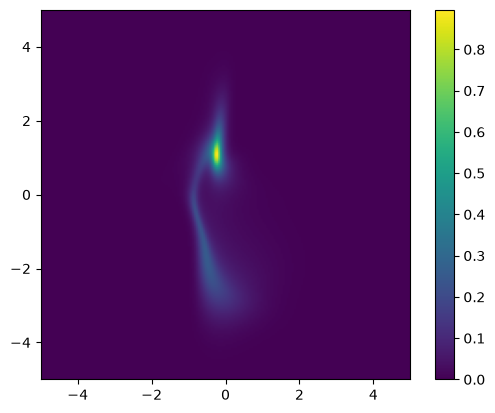

In [11]:
show_density_simple()

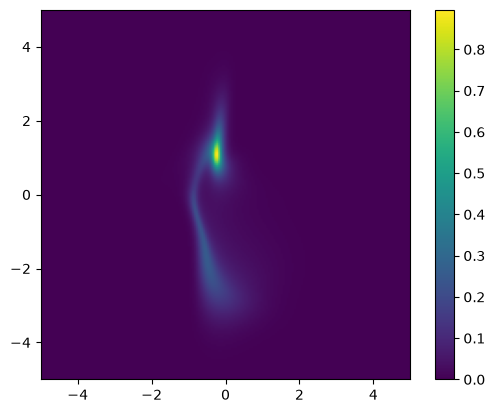

tensor(197.1745, grad_fn=<NegBackward0>)

  5%|████████▊                                                                                                                                                                   | 8/157 [07:16<2:13:32, 53.78s/it]

In [ ]:
from torch.profiler import profile, ProfilerActivity

# activities = [ProfilerActivity.CUDA]

optimizer = torch.optim.Adam(wraped.field.parameters(), lr=0.000001)
step = 0
# history = []
fig, ax = plt.subplots()
out = display(fig, display_id=True)
loss = 0
out2 = display(loss, display_id=True)

# with profile(activities=activities, record_shapes=True, profile_memory=True) as prof:
for _ in range(EPOCHES):
    for X, in tqdm(dataloader):
        # print(X)
        # X = get_batch(BATCH_SIZE)
        Y, log_jac = wraped.forward(X, True)
        Y.requires_grad_()
        loss = CNF.loss_function(2, Y, log_jac)
        optimizer.zero_grad()
        wraped.backward(Y, loss)
        optimizer.step()
        if step % SAVE_AFTER == 0:
            out2.update(loss)
        
            # fig.clear()
            show_density(fig, ax)
            out.update(fig)
            torch.save(cnf.state_dict(), "models/cnf.pt")
            fig.savefig("gallery/fig" + str(step) + ".png")
        # if step == 10:
        #     break
        step+=1
torch.save(cnf.state_dict(), "models/cnf.pt")
# print(prof.key_averages().table(sort_by="self_cuda_time_total", row_limit=20))